In [1]:
import ROOT
%jsroot off
ROOT.gStyle.SetOptStat(0)

In [2]:
canvases = []
stacks = []
legends = []
particles = ['e-', 'mu-', 'pi-', 'kaon-', 'proton']
antiparticles = ['e+', 'mu+', 'pi+', 'kaon+', 'anti_proton']
all_particles = particles + antiparticles

files = {}
for particle in all_particles:
    files[particle] = ROOT.TFile(f'output/matching_performance_{particle}.root', 'read')

# Draw the spectra for each particle

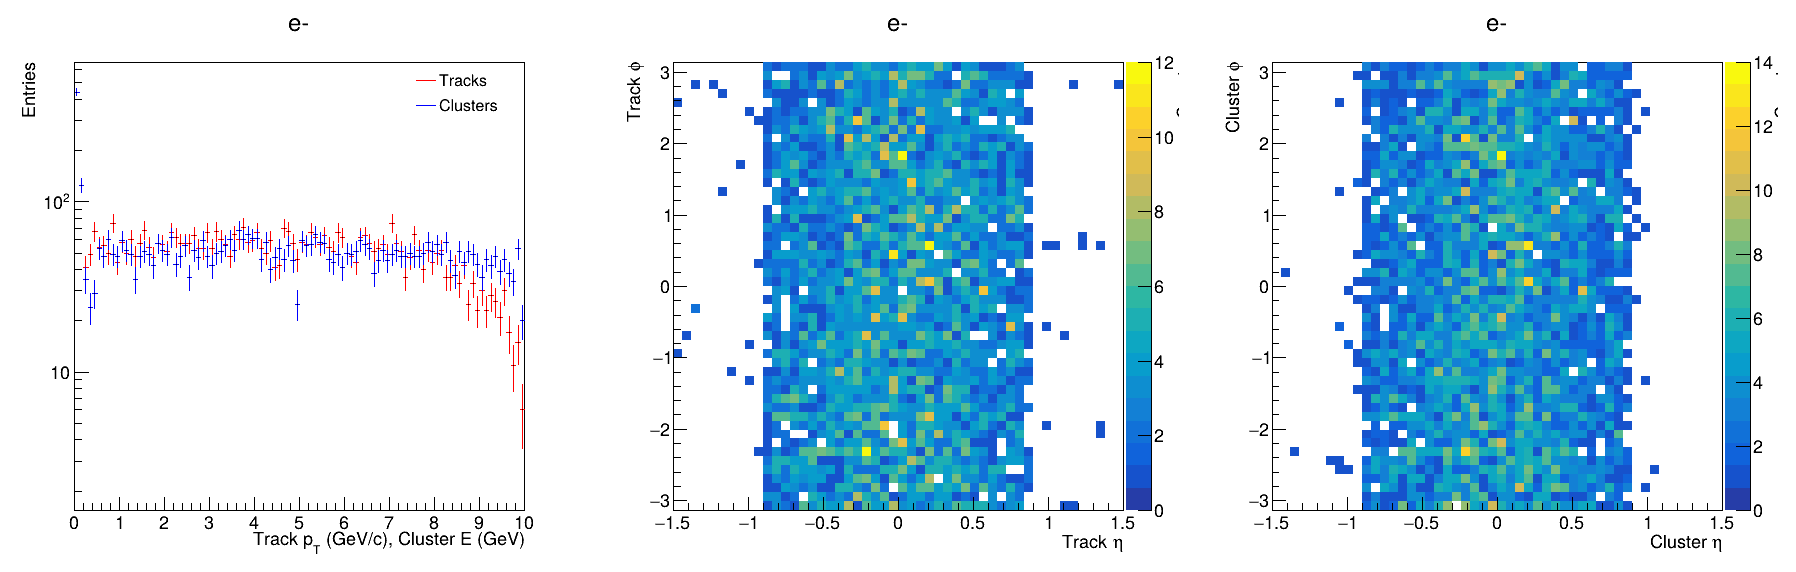

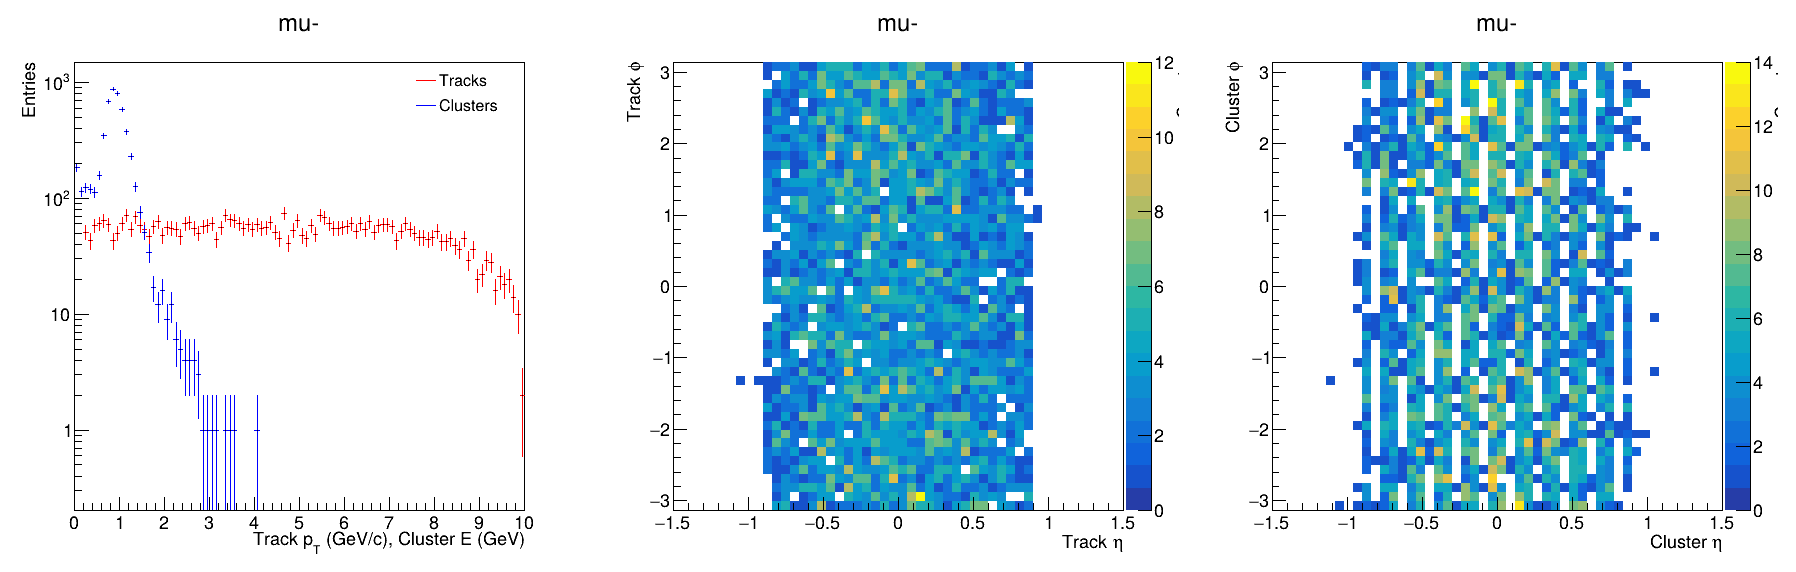

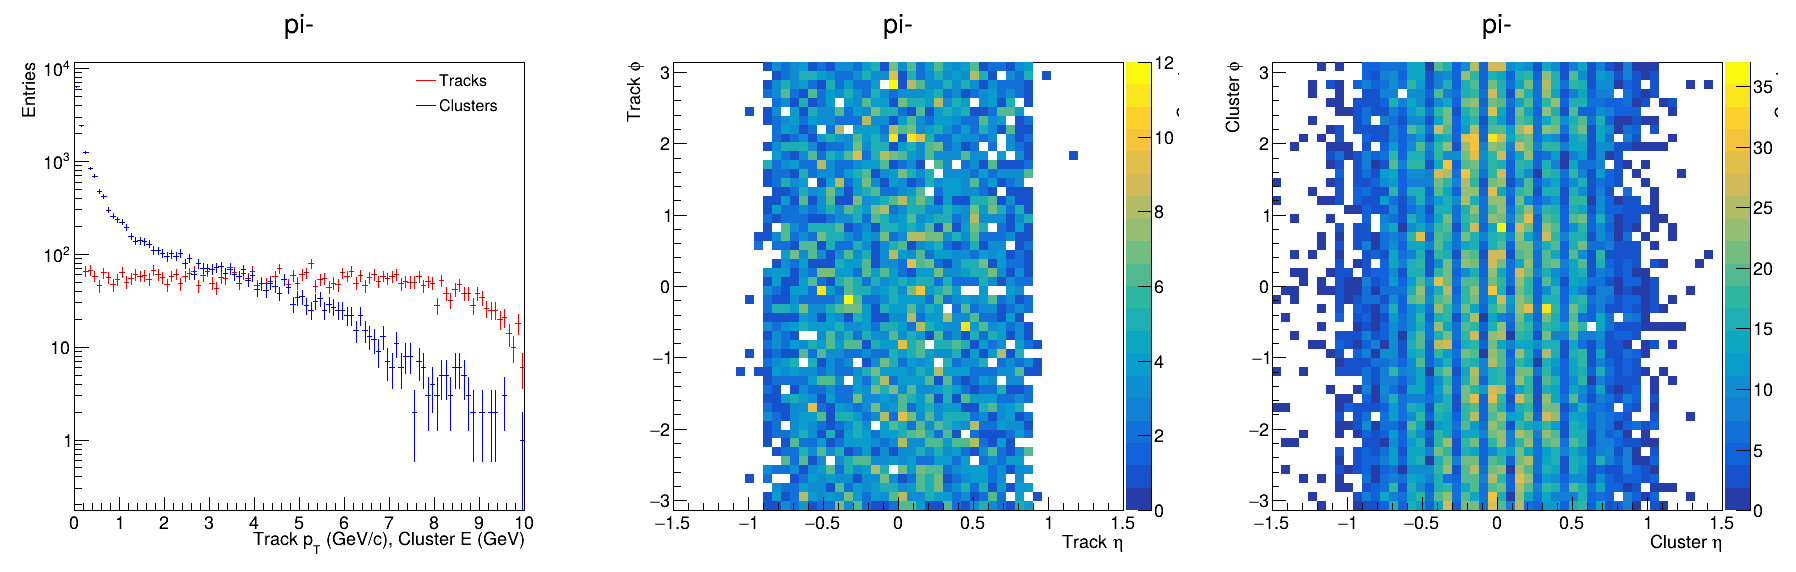

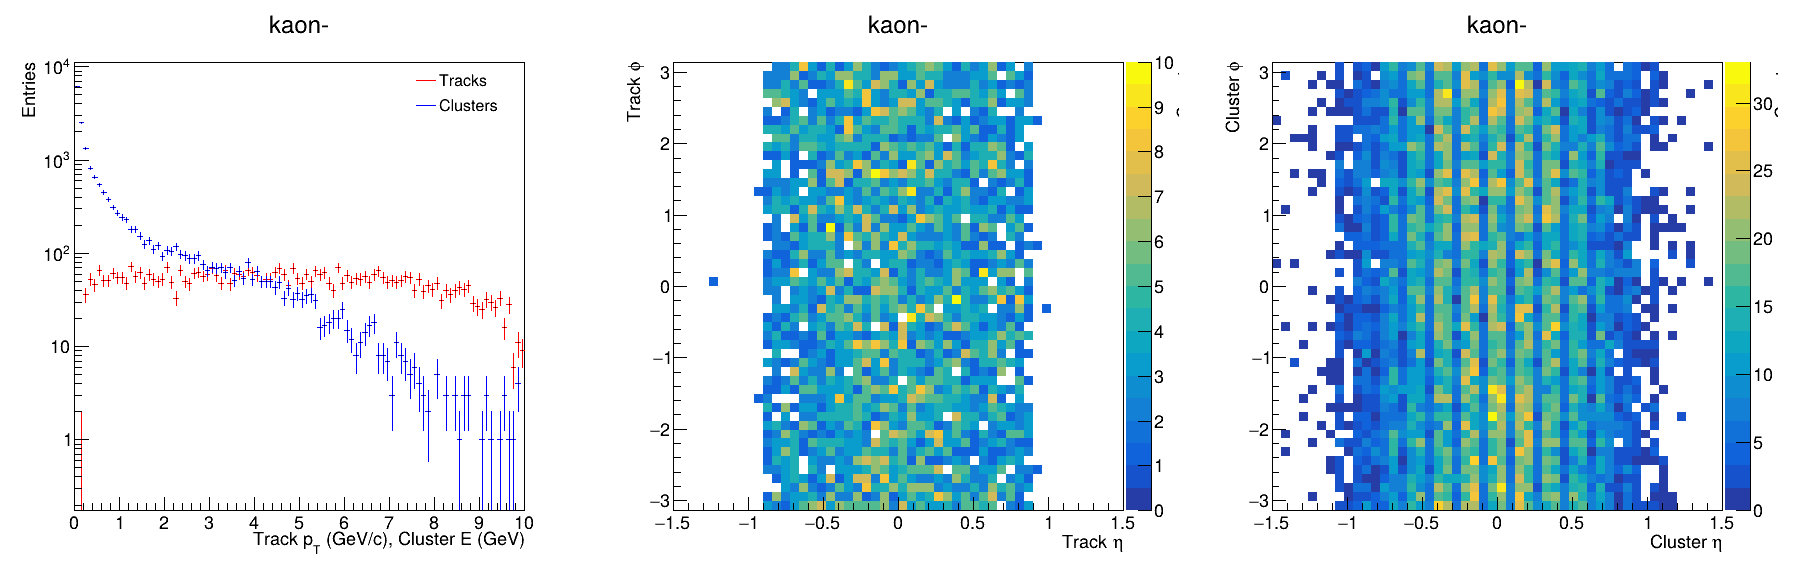

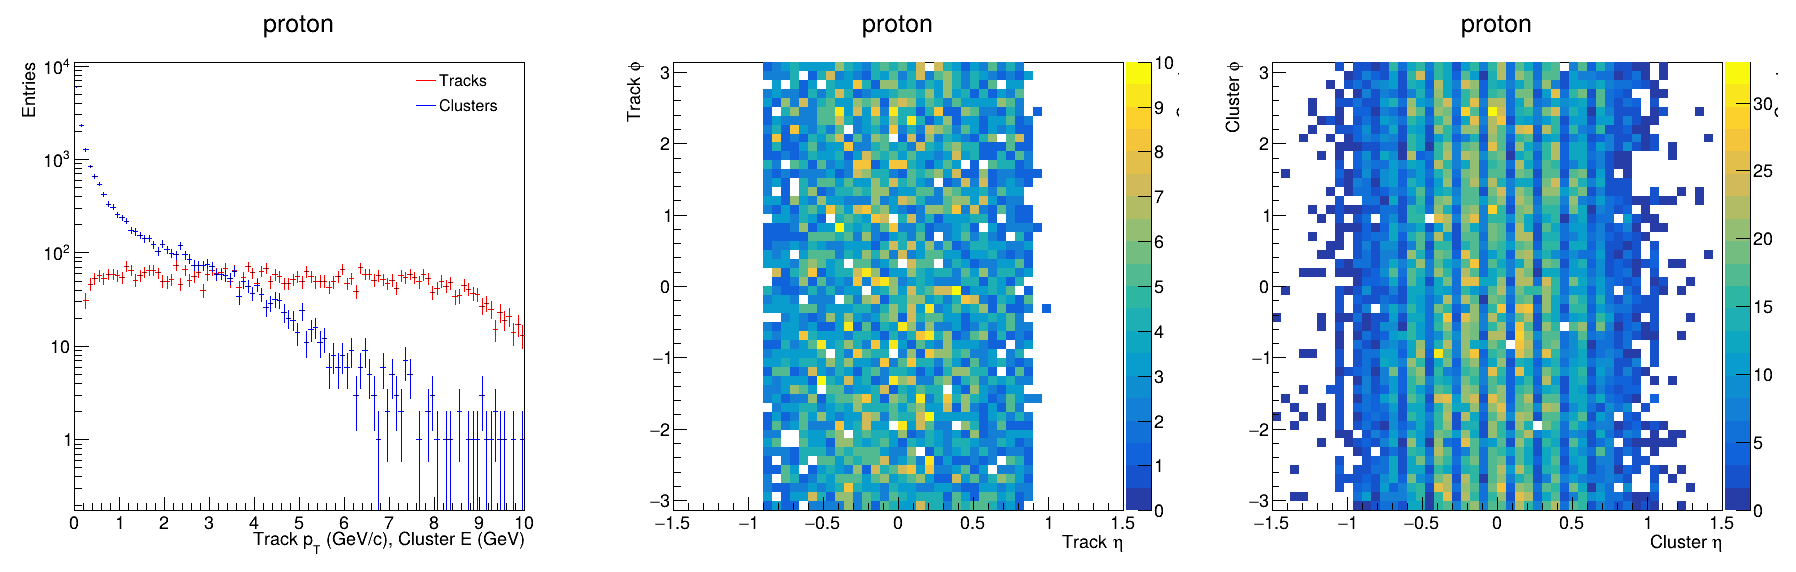

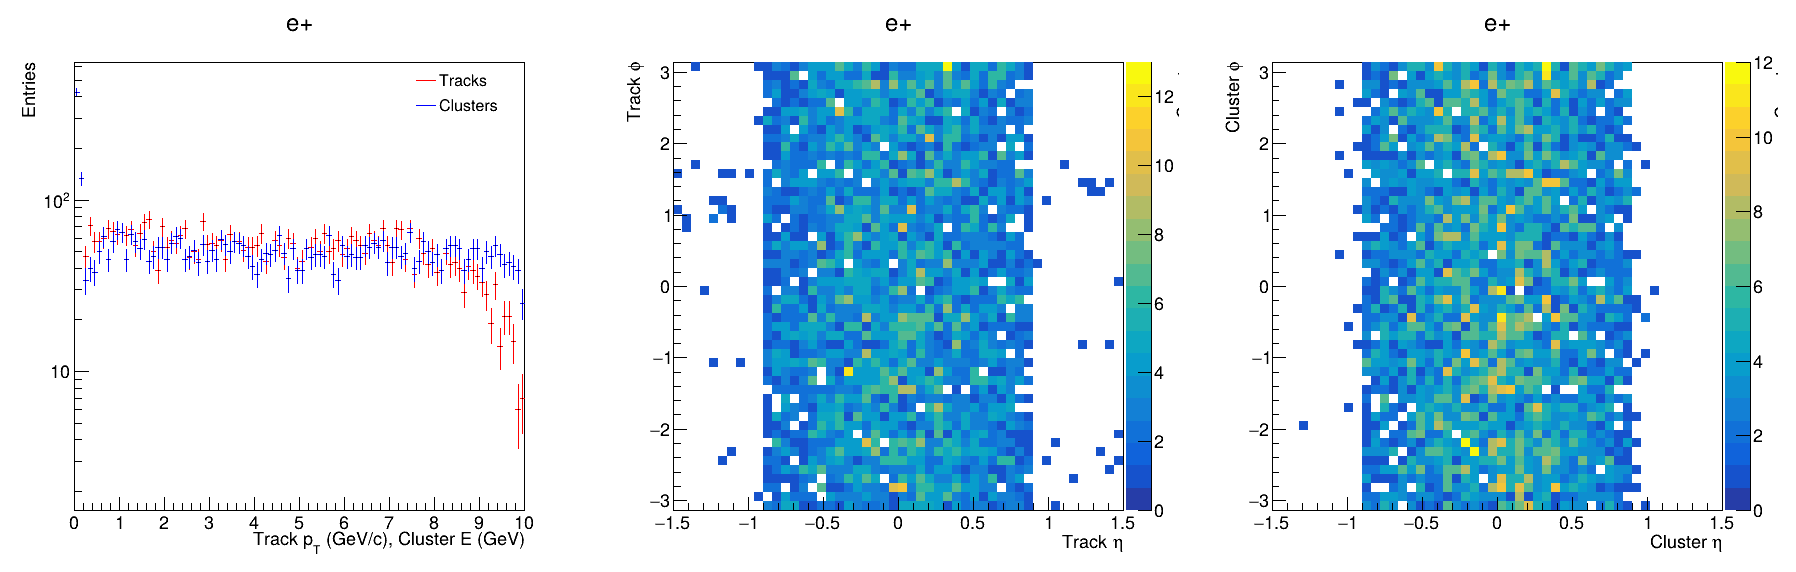

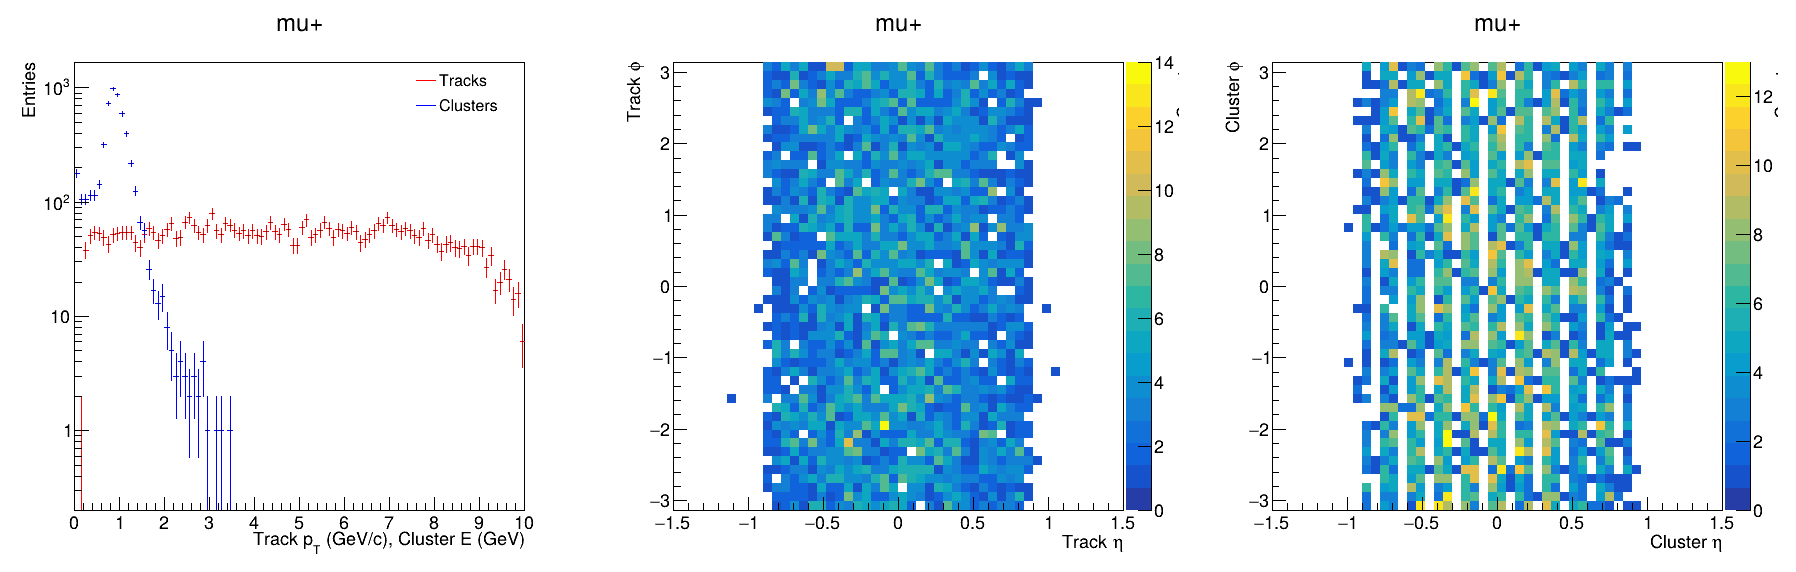

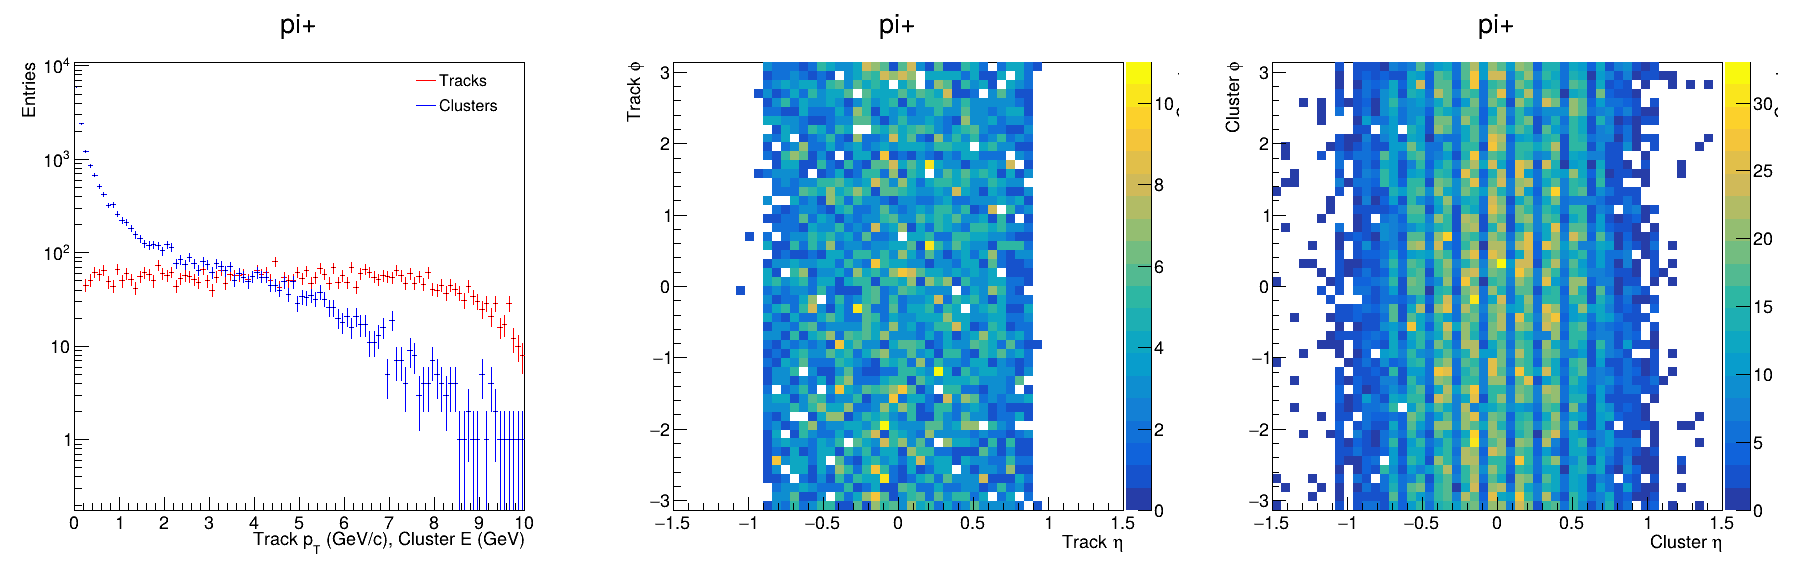

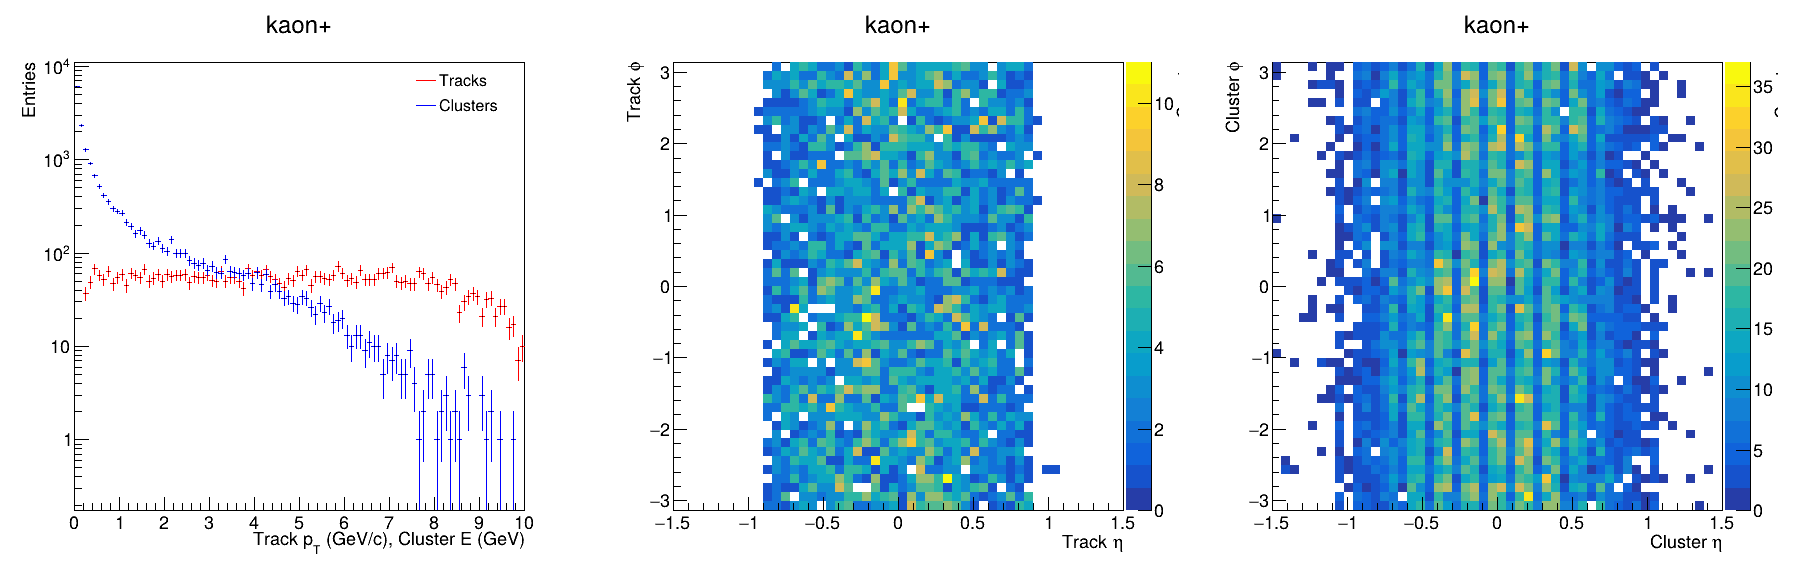

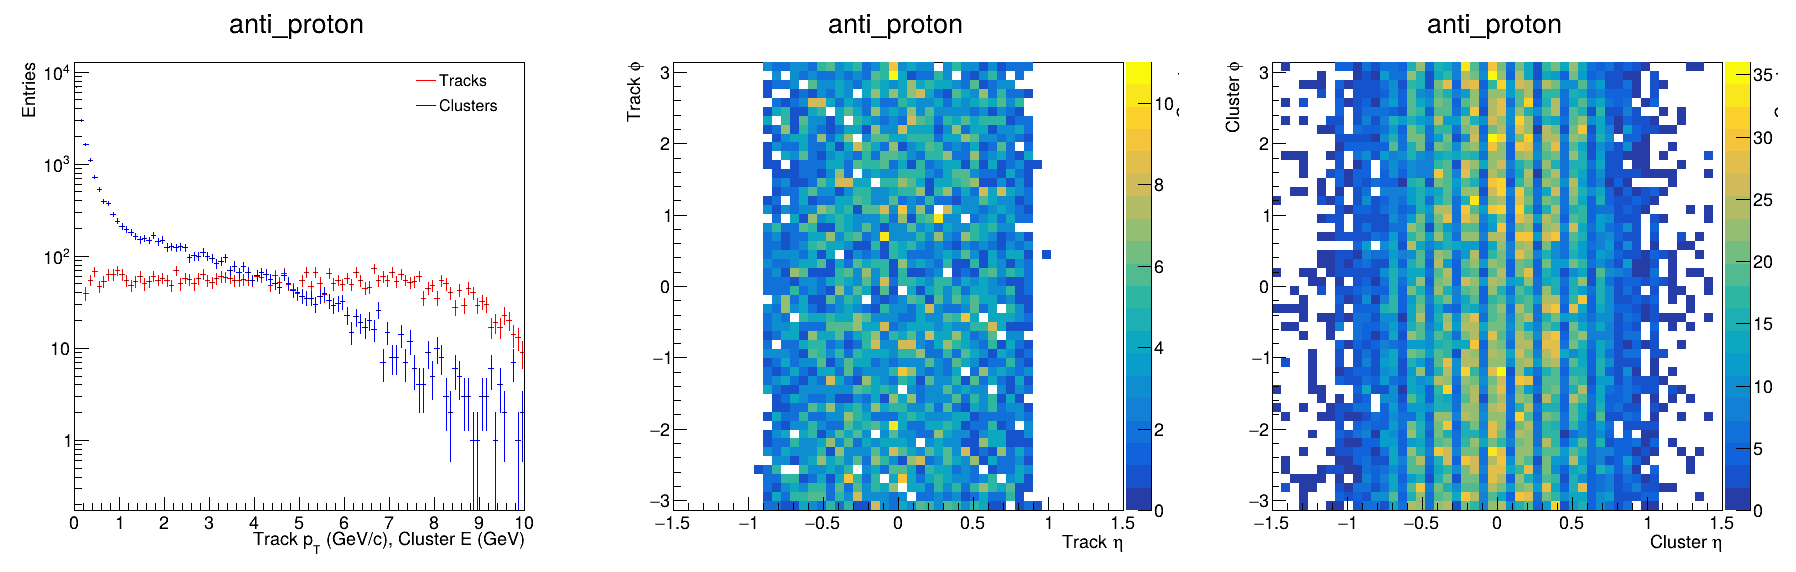

In [3]:
for particle in all_particles:
    c = ROOT.TCanvas(f'c_{particle}', f'c_{particle}', 1800, 600)
    canvases.append(c)
    c.Divide(3, 1)
    c.cd(1)
    stack = ROOT.THStack(f'stack_{particle}_pt', f'stack_{particle}')
    stacks.append(stack)
    legend = ROOT.TLegend(0.7, 0.8, 0.89, 0.89)
    legends.append(legend)
    legend.SetBorderSize(0)

    pt = files[particle].Get('track_pt_distribution')
    pt.SetLineColor(ROOT.kRed)
    stack.Add(pt)
    legend.AddEntry(pt, 'Tracks', 'l')

    E = files[particle].Get('cluster_E_distribution')
    E.SetLineColor(ROOT.kBlue)
    stack.Add(E)
    legend.AddEntry(E, 'Clusters', 'l')
    
    stack.Draw('nostack e')
    ROOT.gPad.SetLogy()
    legend.Draw()
    stack.SetTitle(f'{particle};Track p_{{T}} (GeV/c), Cluster E (GeV);Entries')

    c.cd(2)
    trk_eta_phi = files[particle].Get('track_eta_phi_distribution')
    trk_eta_phi.Draw('colz')
    trk_eta_phi.SetTitle(f'{particle};Track #eta;Track #phi')

    c.cd(3)
    cl_eta_phi = files[particle].Get('cluster_eta_phi_distribution')
    cl_eta_phi.Draw('colz')
    cl_eta_phi.SetTitle(f'{particle};Cluster #eta;Cluster #phi')
    
    c.Draw()

# Matching Performance

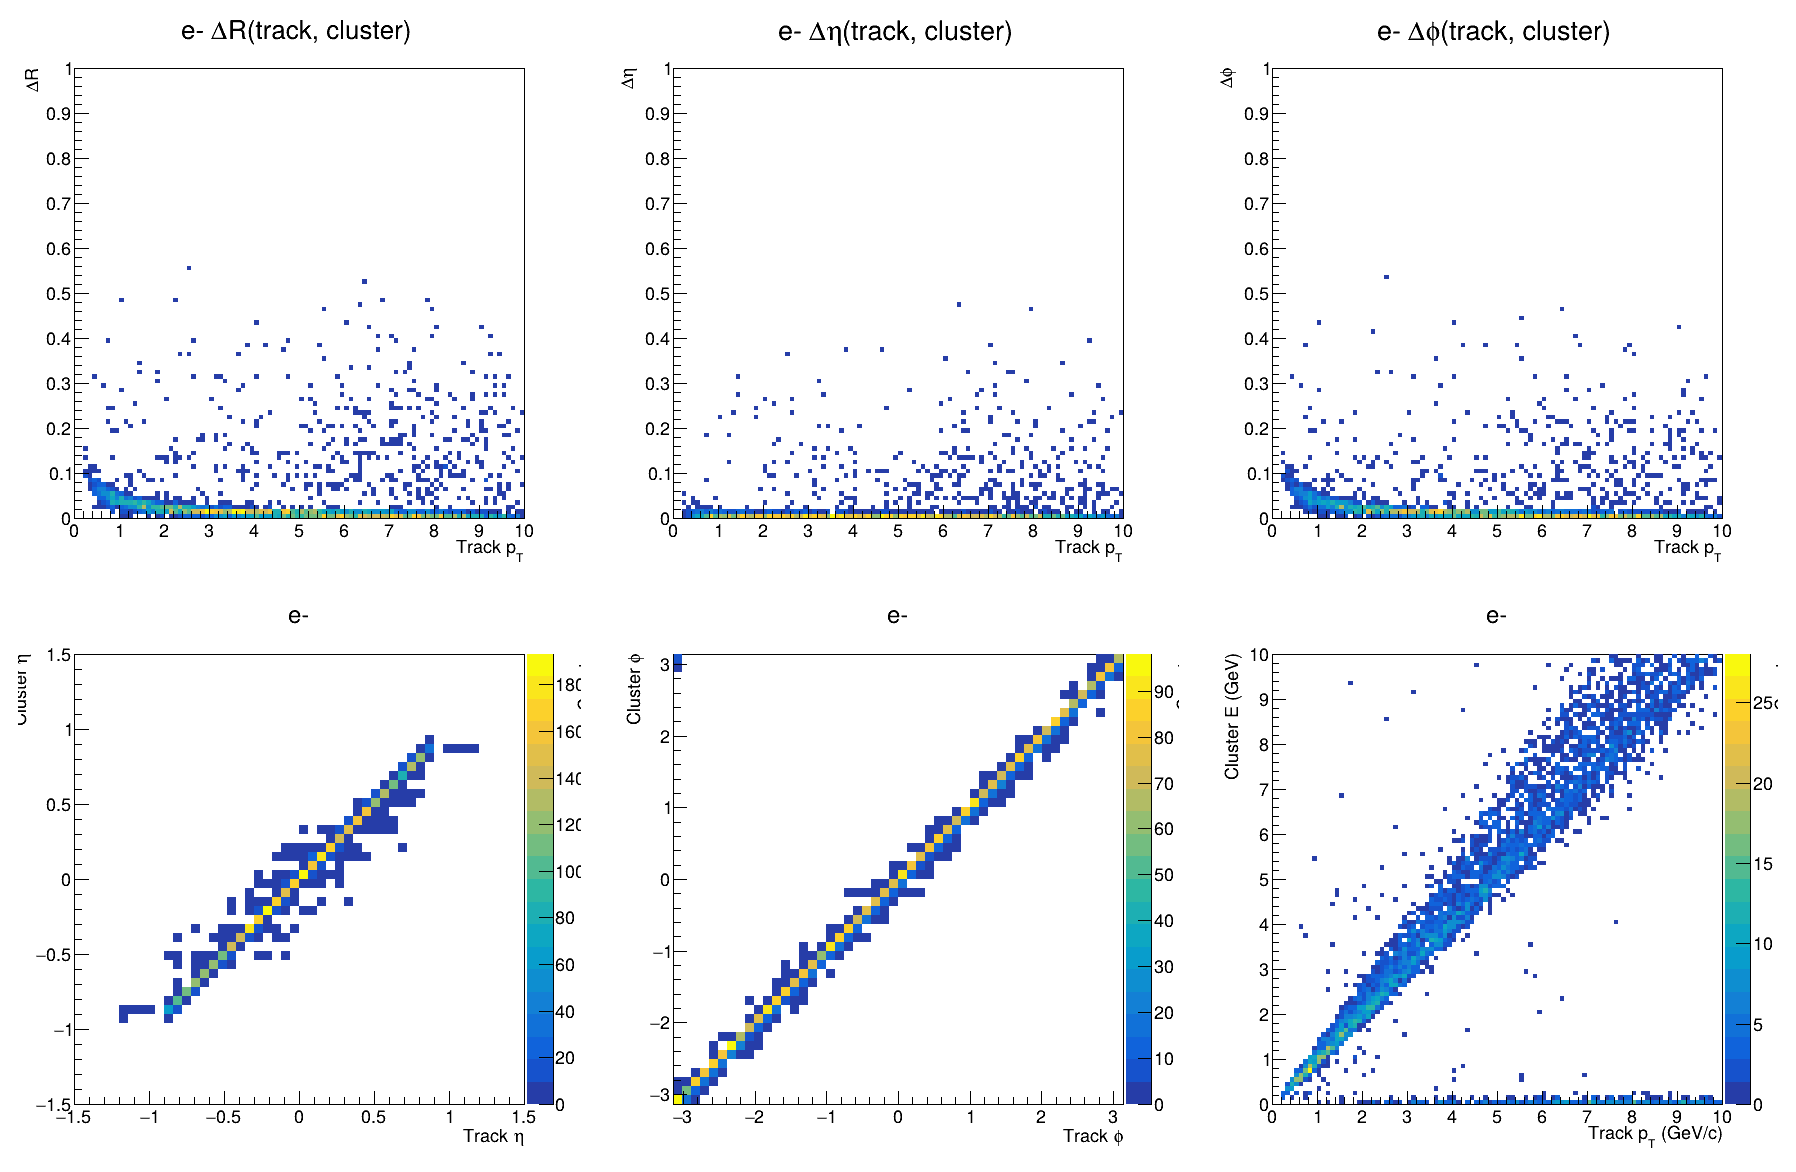

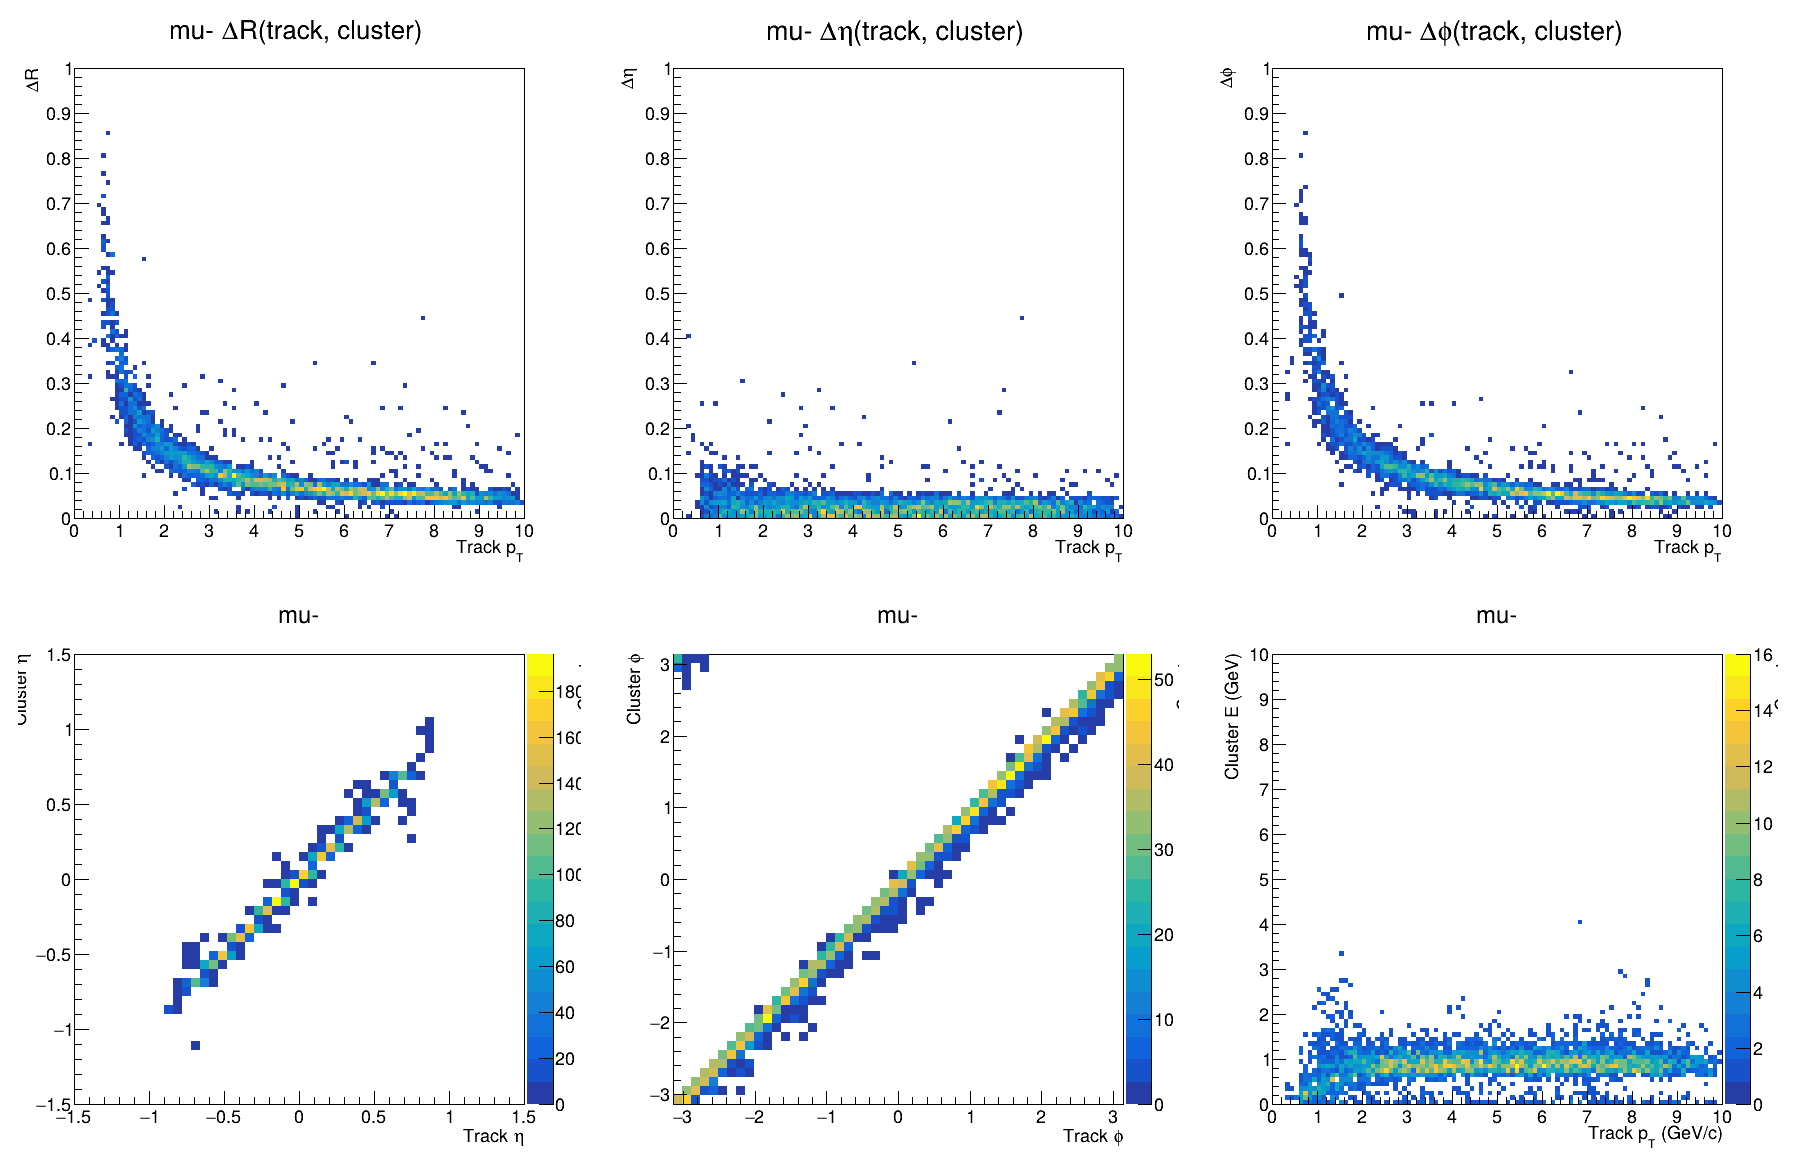

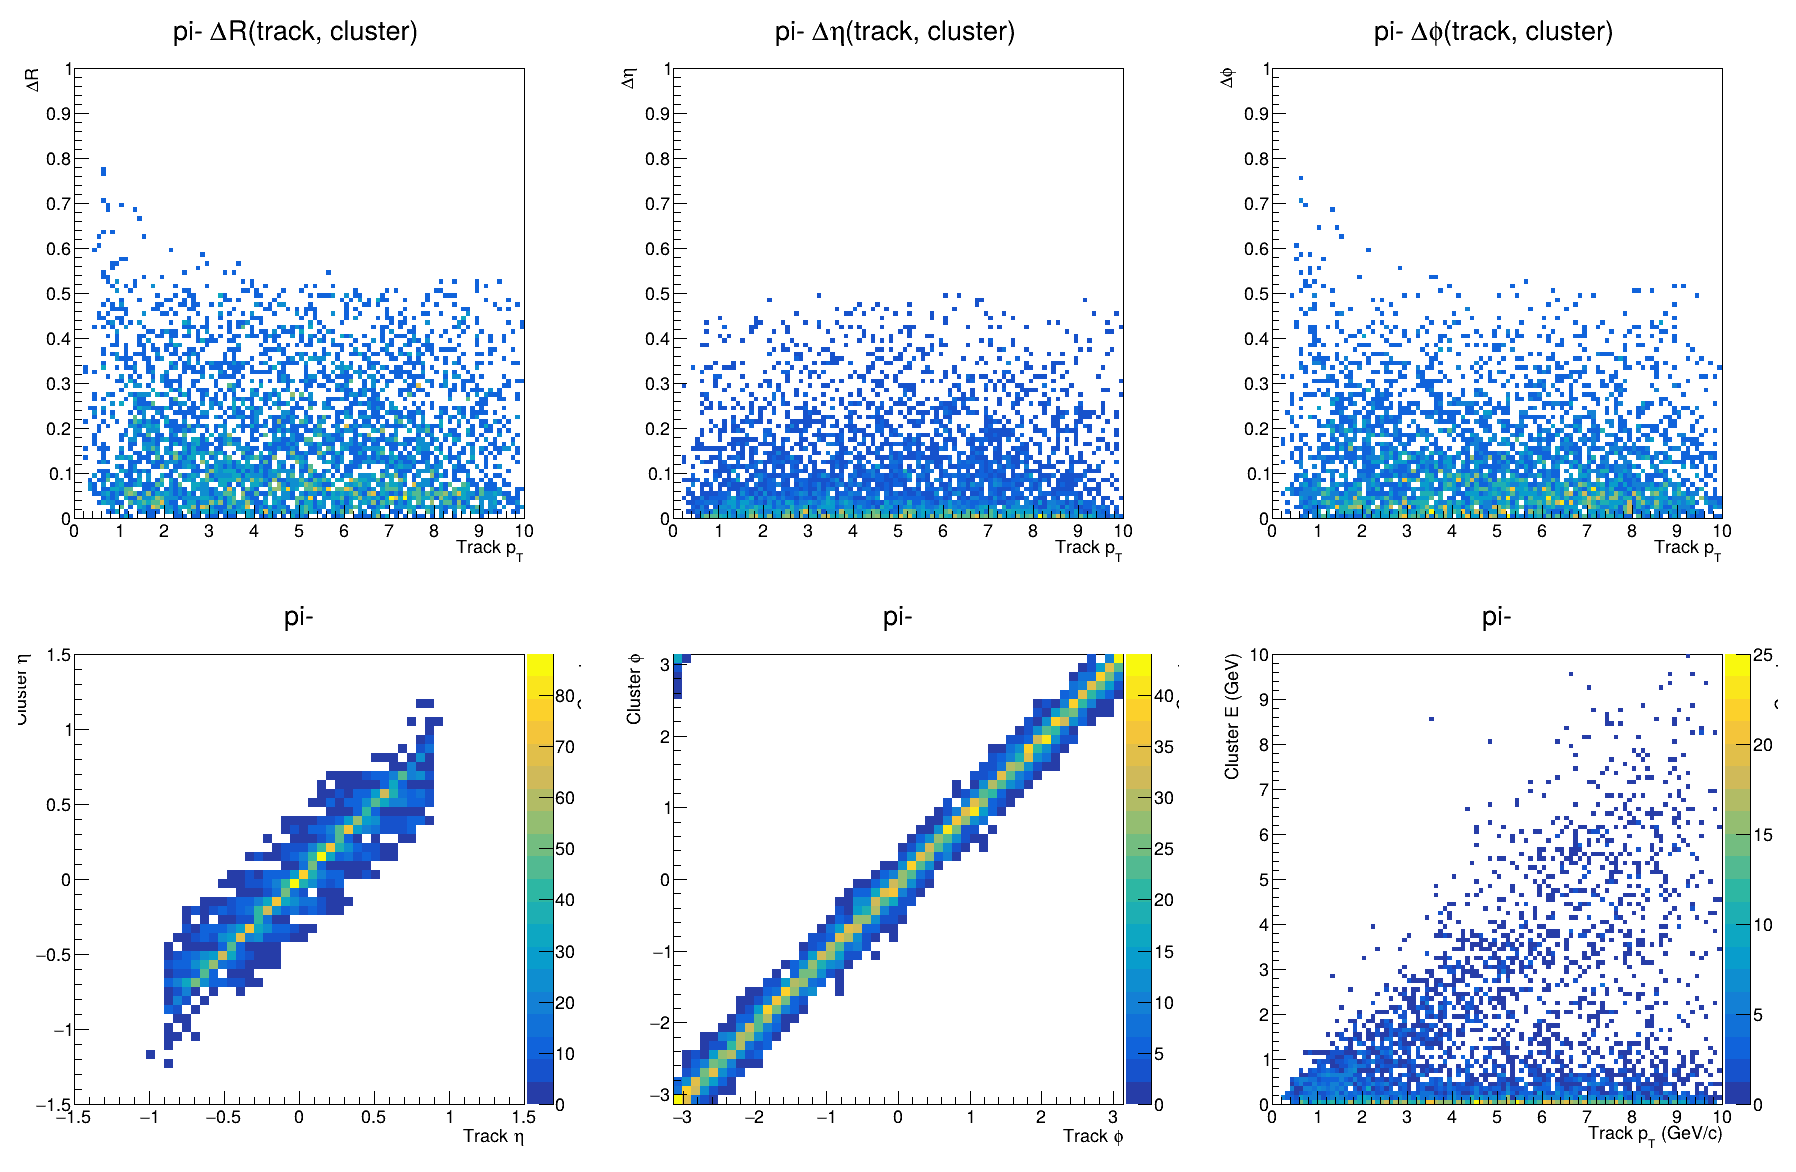

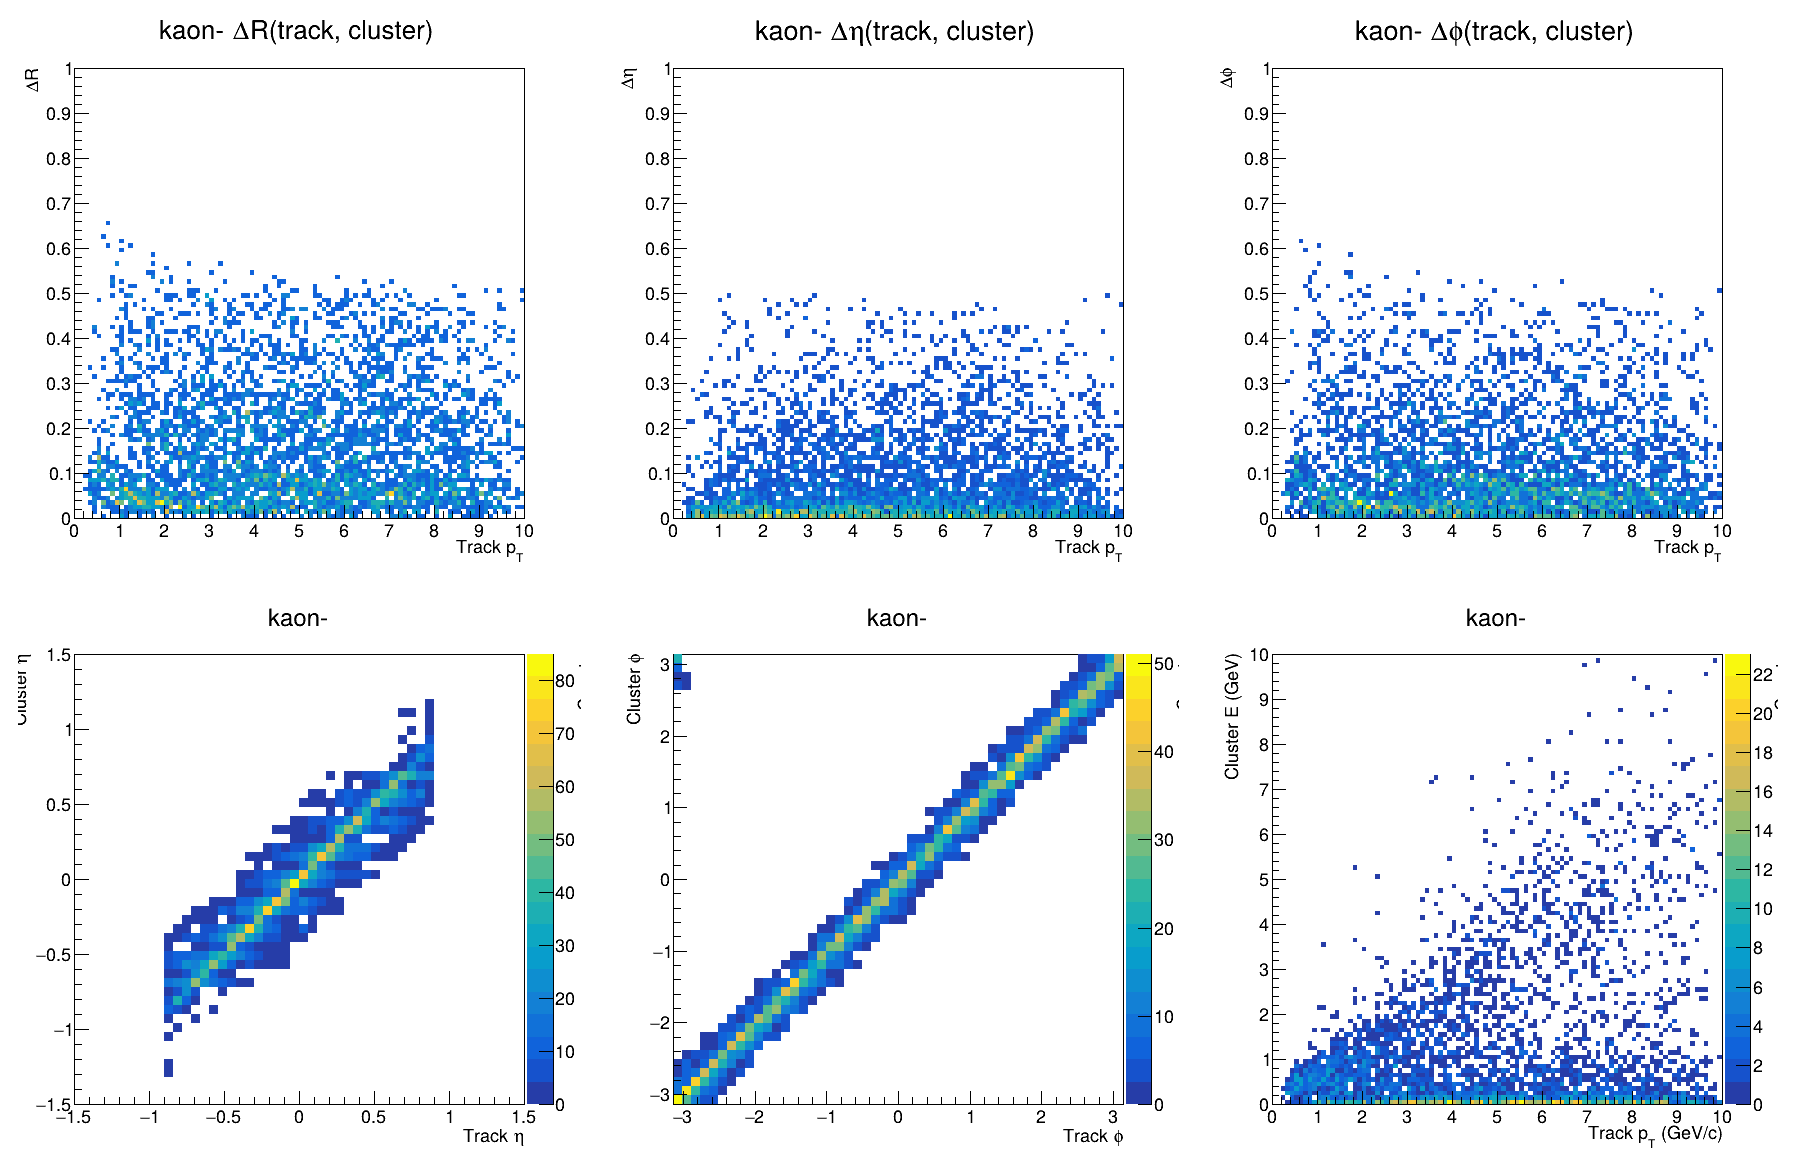

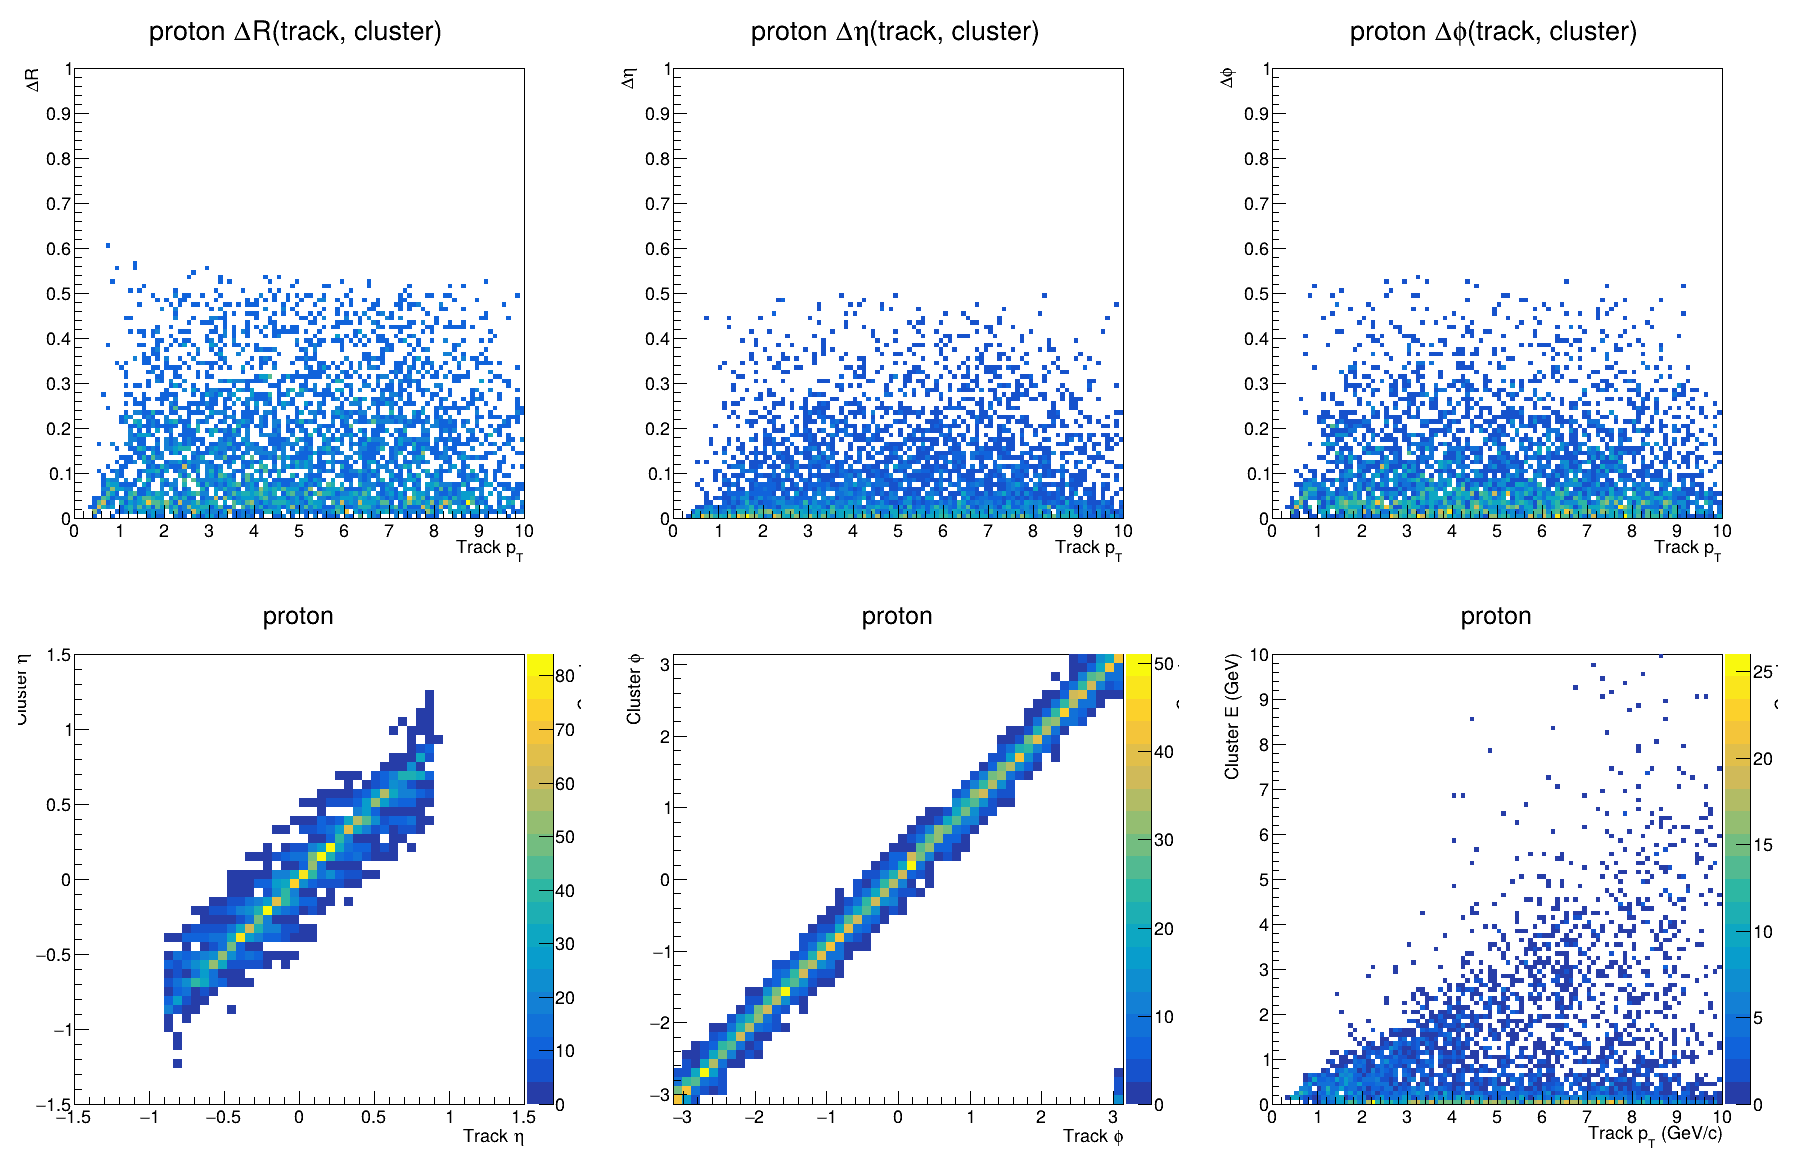

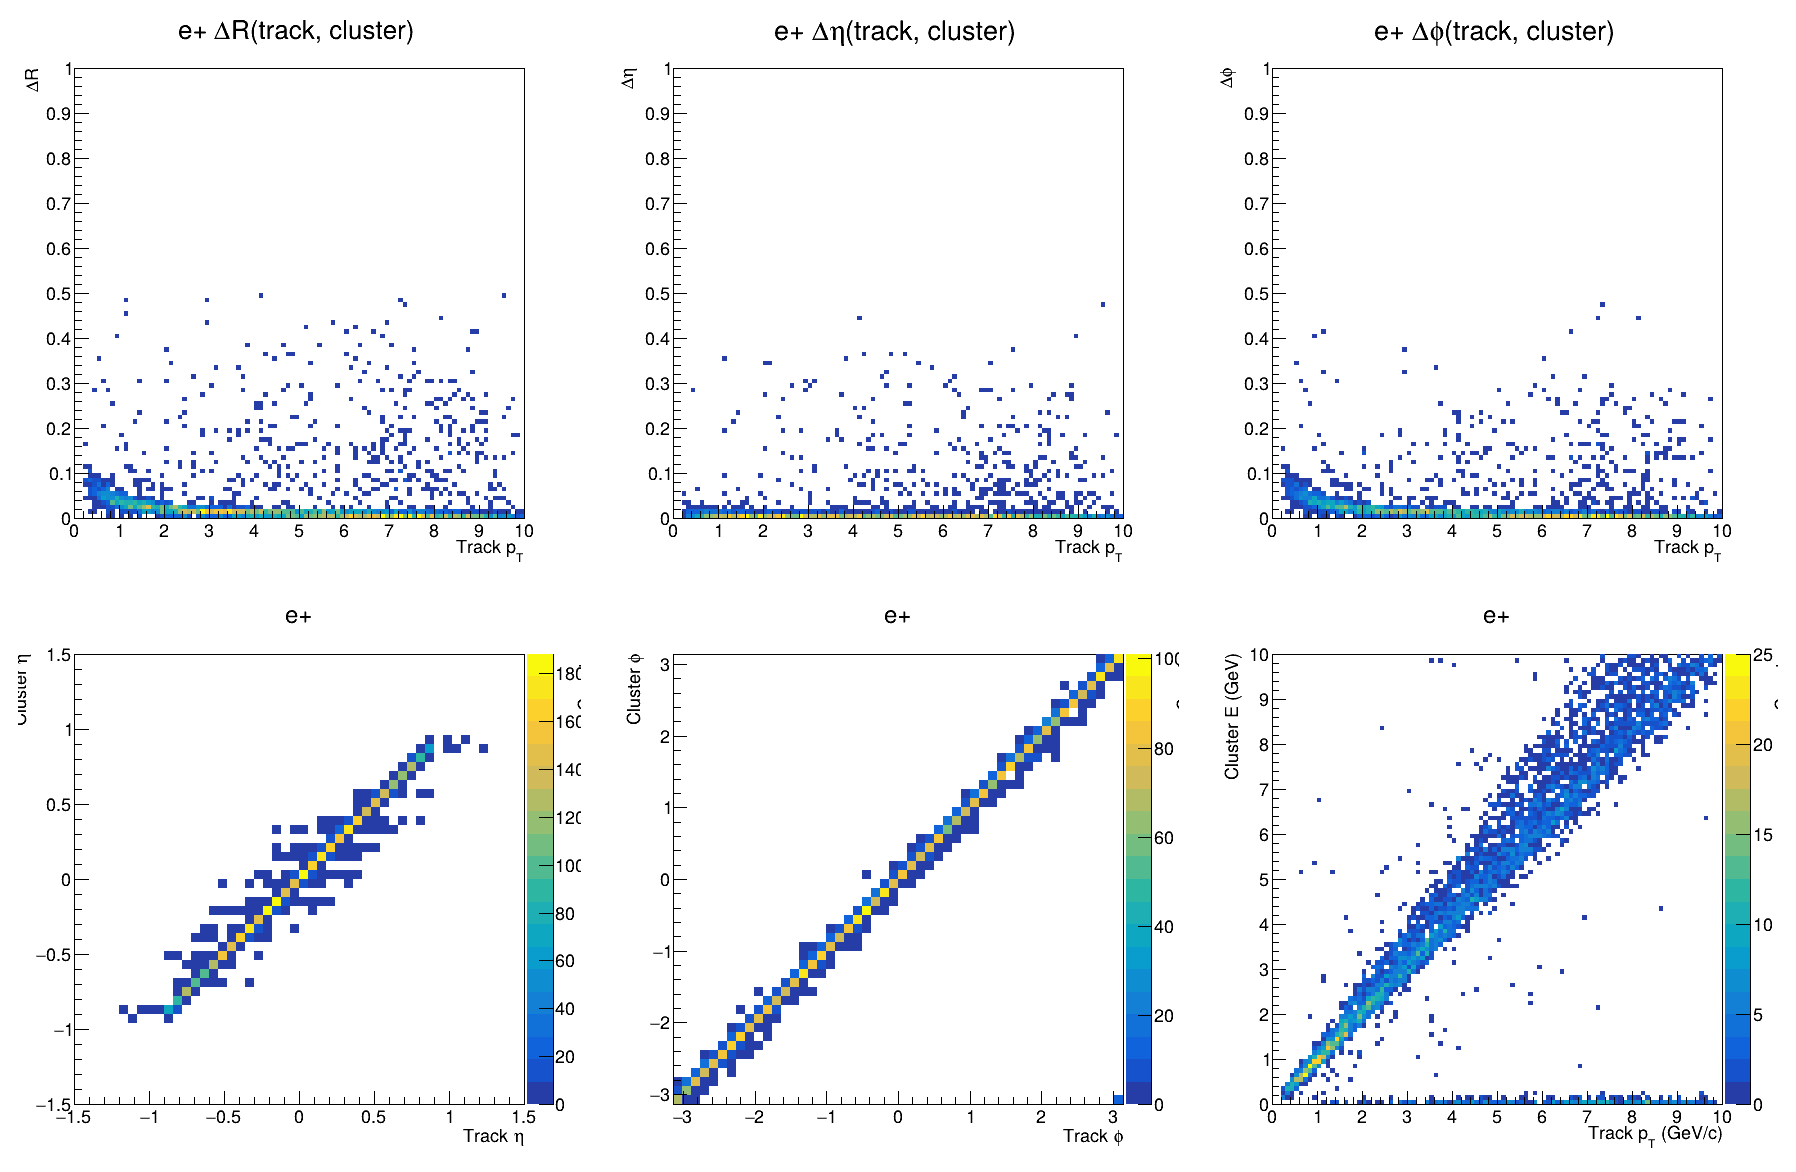

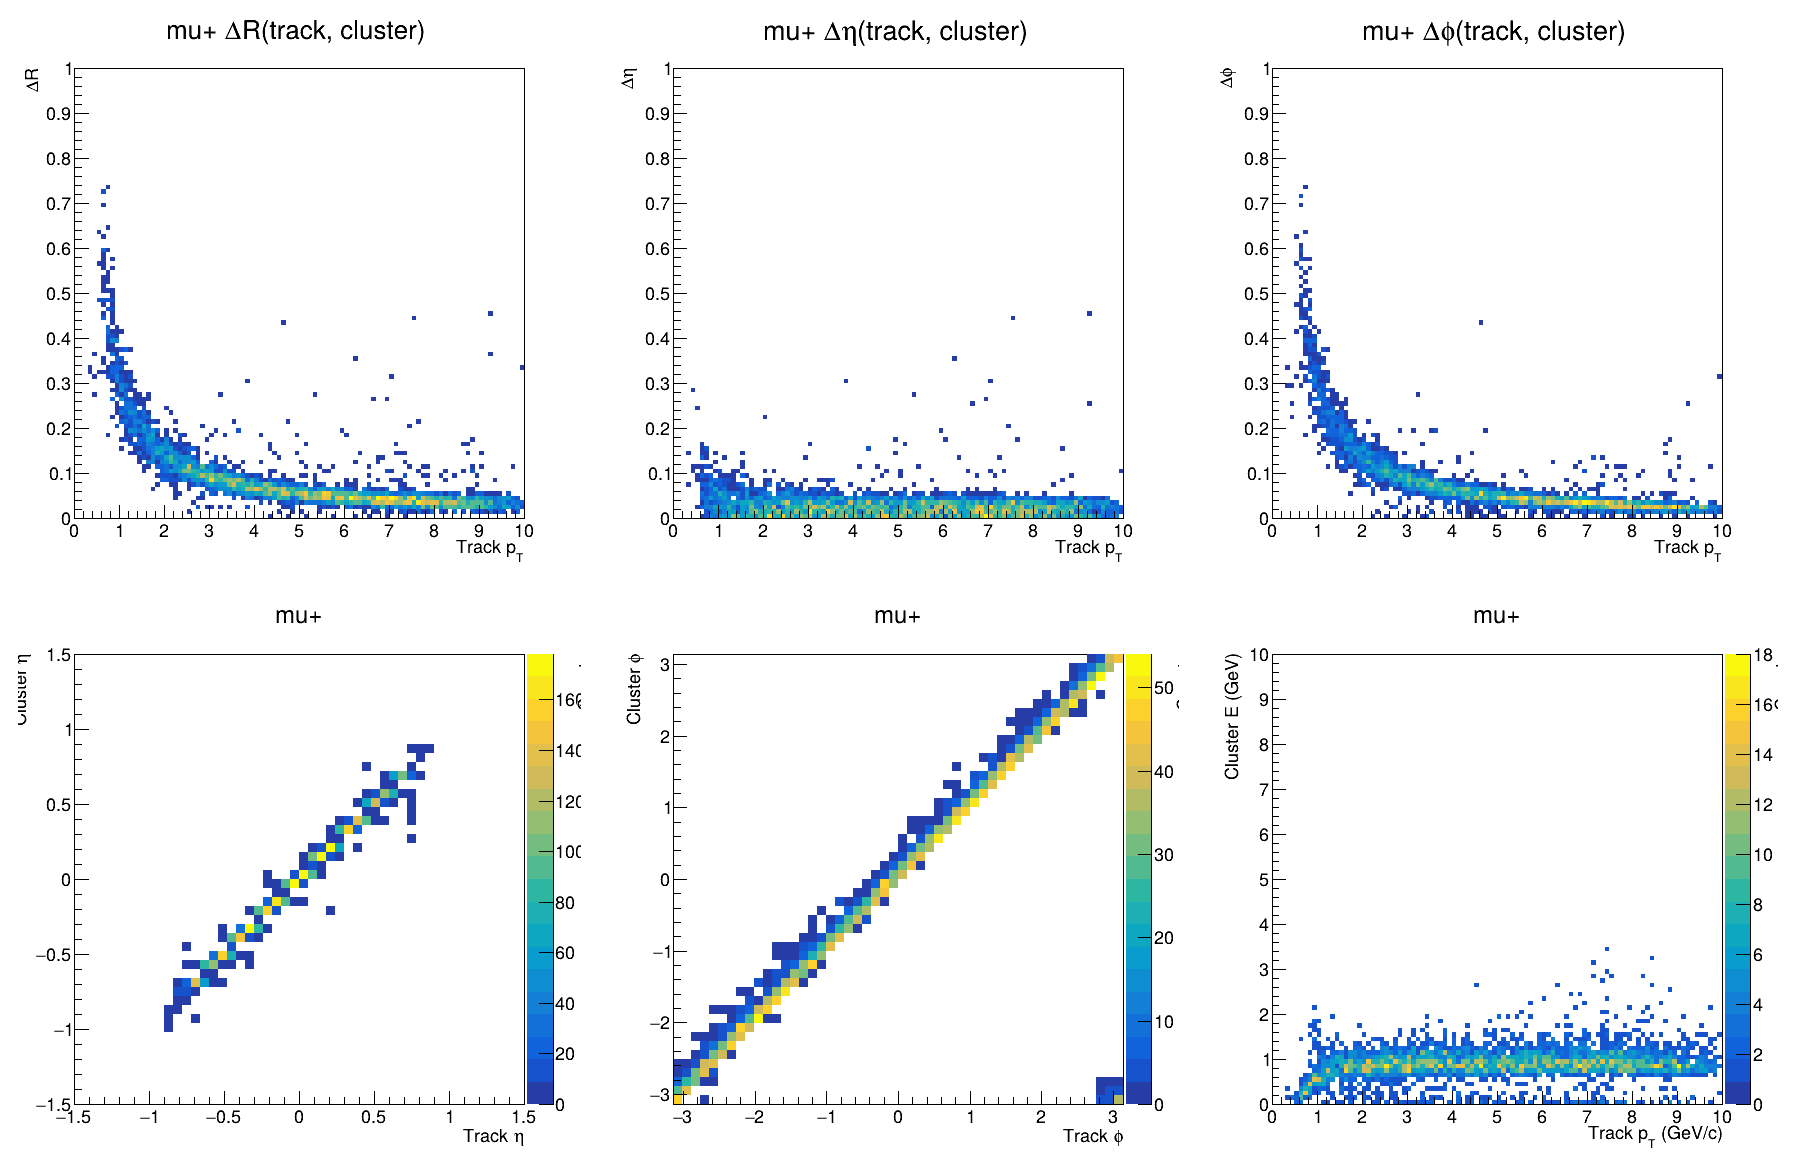

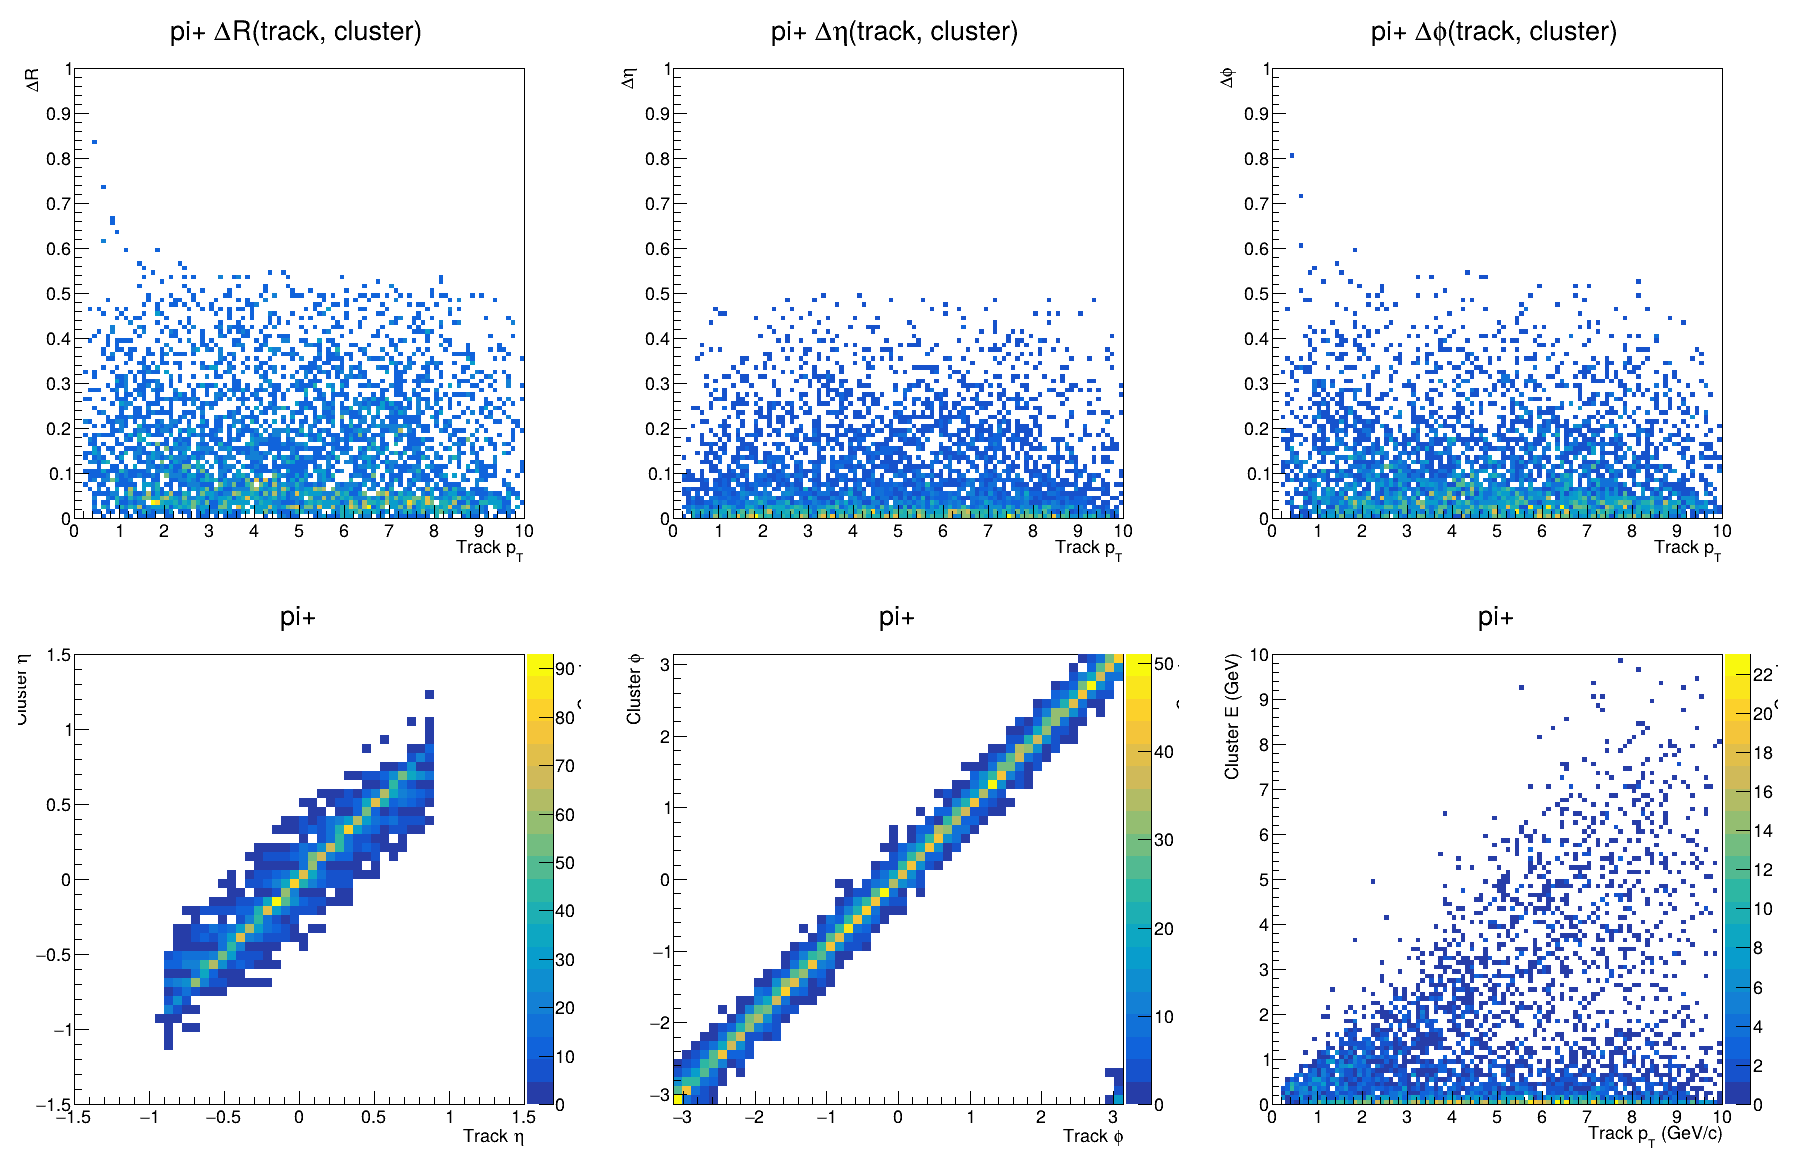

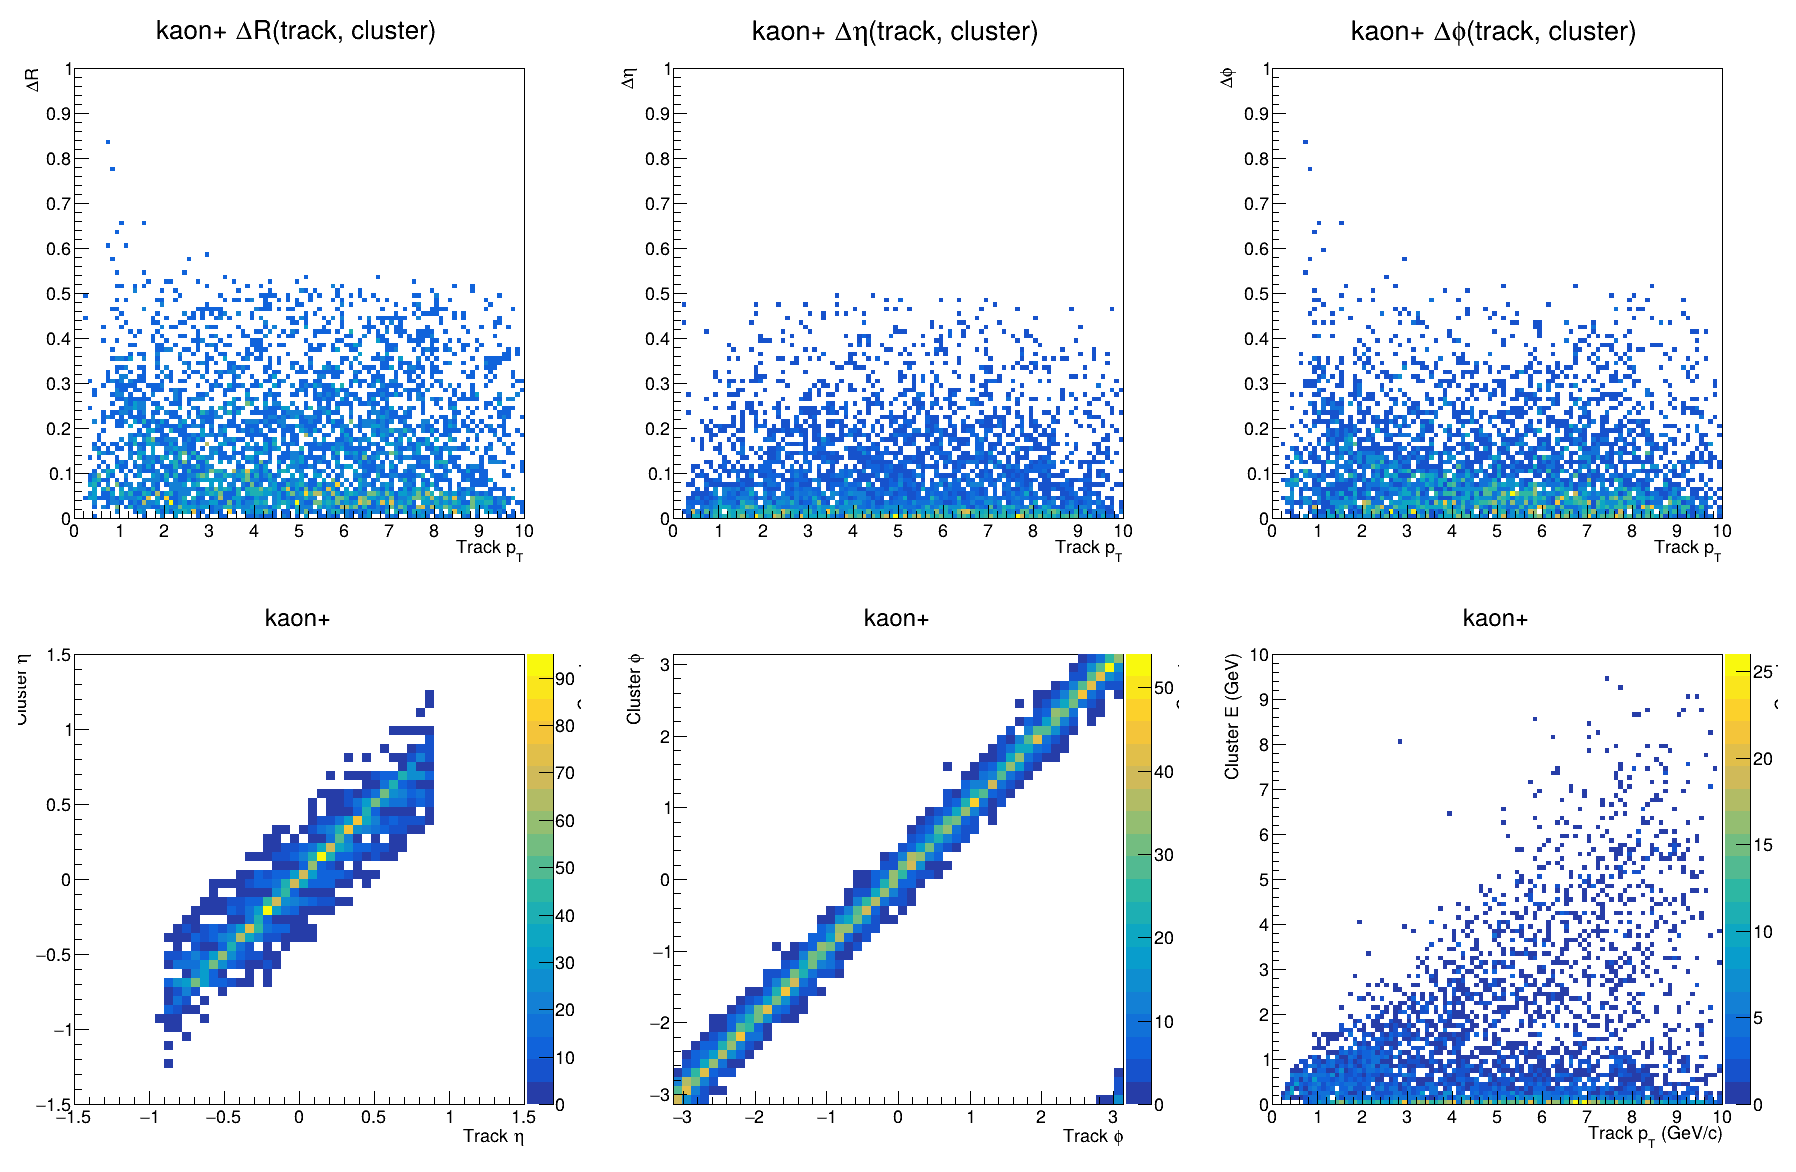

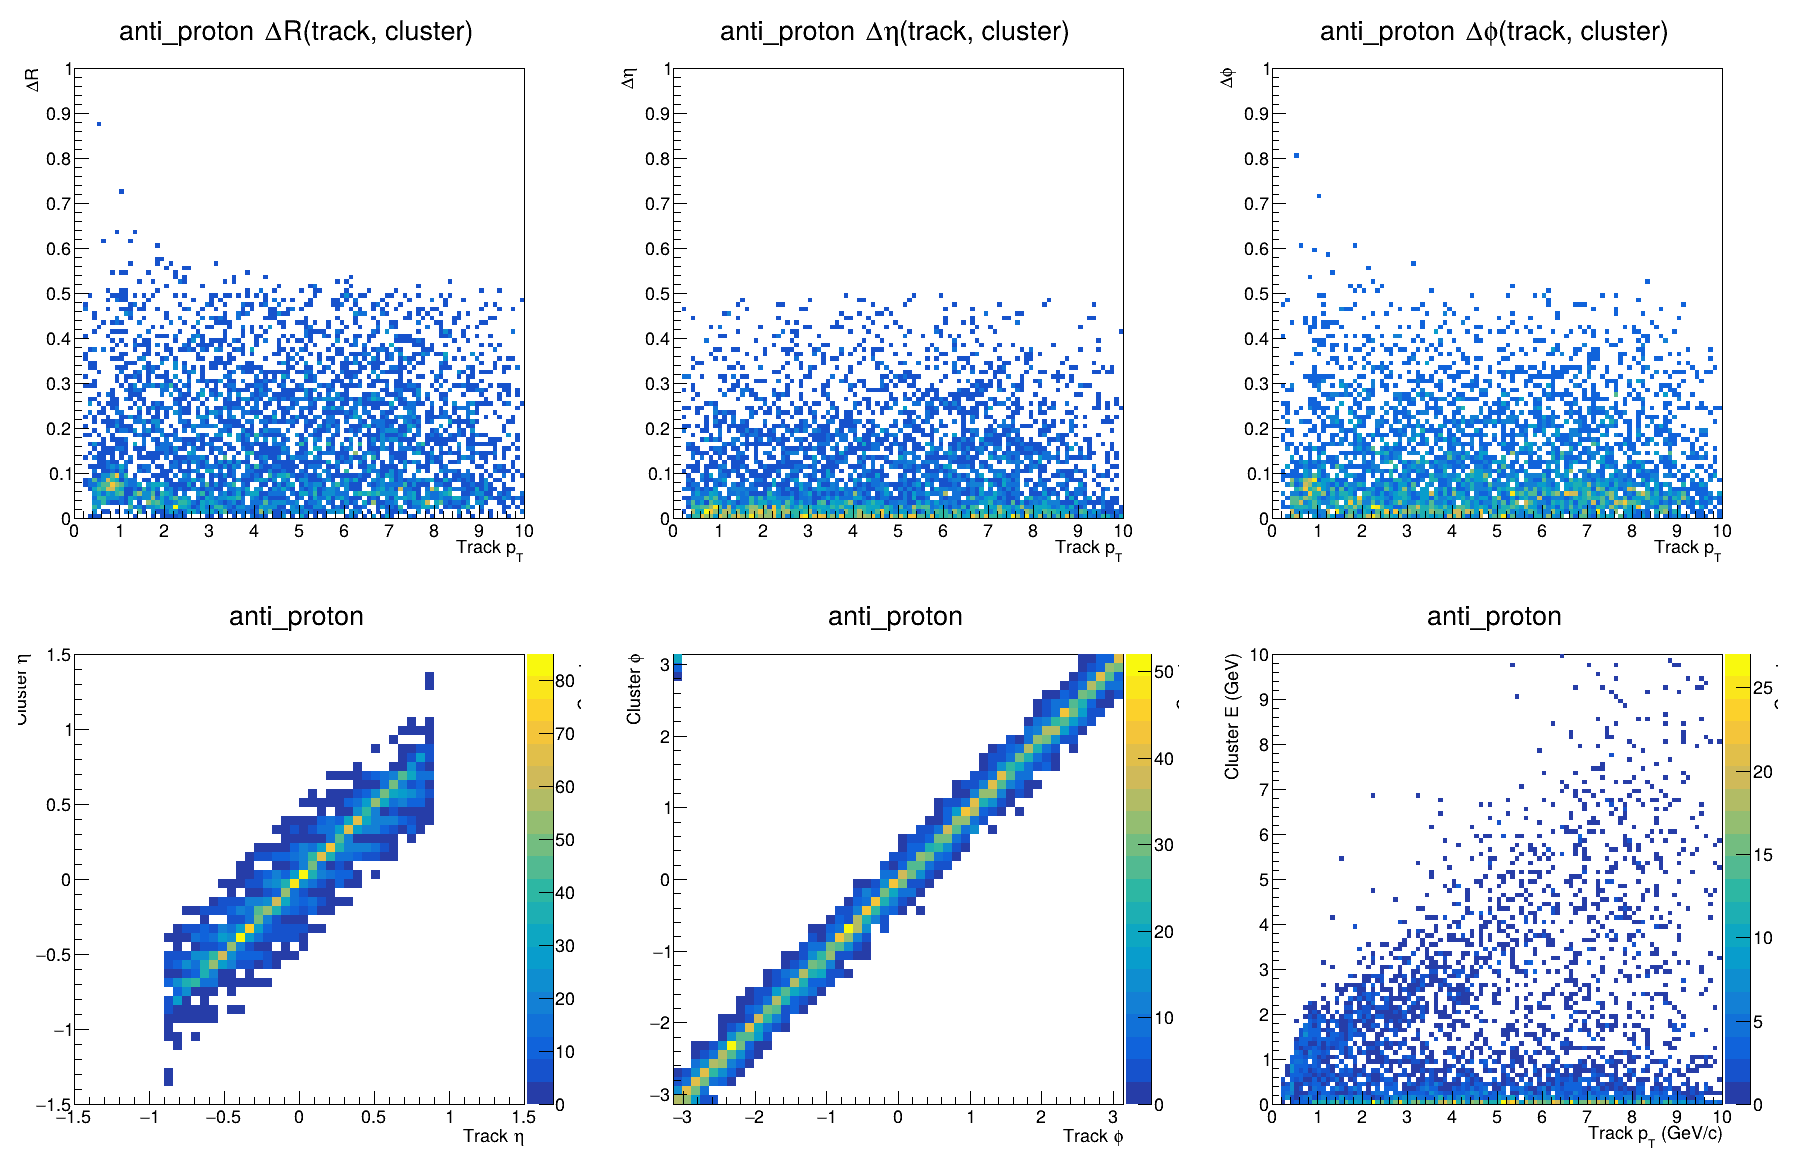

In [4]:
matching_canvases = []

for particle in all_particles:
    c_match = ROOT.TCanvas(f'c_match_{particle}', f'Matching Performance - {particle}', 1800, 1200)
    matching_canvases.append(c_match)
    c_match.Divide(3, 2)
    
    # Delta R
    c_match.cd(1)
    h_dR = files[particle].Get('track_cluster_dR')
    h_dR.SetLineColor(ROOT.kBlue)
    h_dR.SetLineWidth(2)
    h_dR.Draw('hist')
    h_dR.SetTitle(f'{particle} #DeltaR(track, cluster);Track p_{{T}};#DeltaR')
    
    # Delta Eta
    c_match.cd(2)
    h_dEta = files[particle].Get('track_cluster_dEta')
    h_dEta.SetLineColor(ROOT.kRed)
    h_dEta.SetLineWidth(2)
    h_dEta.Draw('hist')
    h_dEta.SetTitle(f'{particle} #Delta#eta(track, cluster);Track p_{{T}};#Delta#eta')
    
    # Delta Phi
    c_match.cd(3)
    h_dPhi = files[particle].Get('track_cluster_dPhi')
    h_dPhi.SetLineColor(ROOT.kGreen+2)
    h_dPhi.SetLineWidth(2)
    h_dPhi.Draw('hist')
    h_dPhi.SetTitle(f'{particle} #Delta#phi(track, cluster);Track p_{{T}};#Delta#phi')
    
    # Cluster eta vs track eta
    c_match.cd(4)
    h_eta_corr = files[particle].Get('track_cluster_eta')
    h_eta_corr.Draw('colz')
    h_eta_corr.SetTitle(f'{particle};Track #eta;Cluster #eta')
    
    # Cluster phi vs track phi
    c_match.cd(5)
    h_phi_corr = files[particle].Get('track_cluster_phi')
    h_phi_corr.Draw('colz')
    h_phi_corr.SetTitle(f'{particle};Track #phi;Cluster #phi')

    # Cluster E vs track pT
    c_match.cd(6)
    h_E_corr = files[particle].Get('track_cluster_E')
    h_E_corr.Draw('colz')
    h_E_corr.SetTitle(f'{particle};Track p_{{T}} (GeV/c);Cluster E (GeV)')
    
    c_match.Draw()

Warning in <TFile::Append>: Replacing existing TH1: dummy (Potential memory leak).


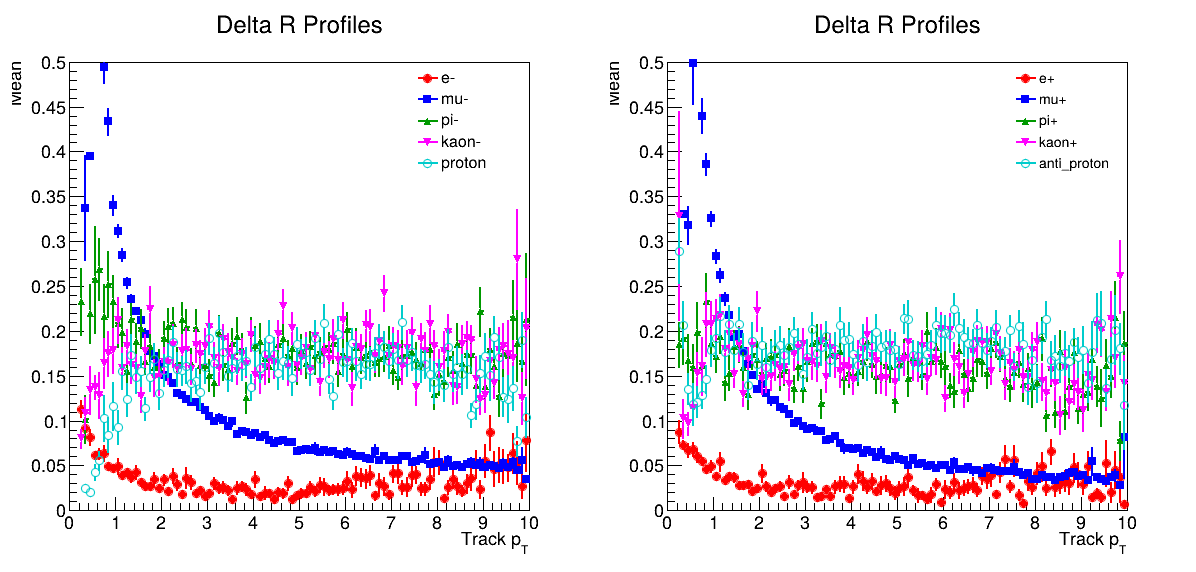

In [5]:
profiles = []
c_profiles = ROOT.TCanvas("c_dR_profiles", "Delta R Profiles", 1200, 600)
c_profiles.cd()
canvases.append(c_profiles)
c_profiles.Divide(2, 1)
c_num = 1
for collection in (particles, antiparticles):
    c_profiles.cd(c_num)
    c_num += 1

    # Create a legend
    legend_profiles = ROOT.TLegend(0.7, 0.7, 0.89, 0.89)
    legend_profiles.SetBorderSize(0)
    legends.append(legend_profiles)

    # Define a list of colors to use
    colors = [ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2, ROOT.kMagenta, ROOT.kCyan+1,
            ROOT.kOrange+7, ROOT.kViolet-3, ROOT.kSpring+9, ROOT.kTeal-7, ROOT.kAzure+1]

    first = True

    dummy = ROOT.TH1F("dummy", "dummy", 1, 0, 10)
    dummy.Draw()
    dummy.GetYaxis().SetRangeUser(0, 0.5)
    dummy.SetTitle("Delta R Profiles;Track p_{T};Mean")


    # Loop through particles
    for i, particle in enumerate(collection):
        # Get the delta R histogram
        h_dR = files[particle].Get('track_cluster_dR')
        
        # Create profile
        prof = h_dR.ProfileX(f"prof_{particle}")
        profiles.append(prof)
        
        # Set style
        prof.SetLineColor(colors[i])
        prof.SetMarkerColor(colors[i])
        prof.SetMarkerStyle(20 + i)
        prof.SetLineWidth(2)
        
        prof.Draw("same")
        
        legend_profiles.AddEntry(prof, particle, "lp")

    legend_profiles.Draw()
    c_profiles.Update()